# Fluctuations in periodic states
We consider fluctuations of the effective model

$$
H_\textrm{eff} = - \sum_\square \ket{+}\bra{-} + \mu \sum_{\square} \ket{+}\bra{+} +\textrm{h.c.}
$$

The hilbert space fragments into disjoint sectors which are inaccessible to each other by local plaquette moves.

$$
H_\textrm{eff} = \begin{pmatrix}
\begin{pmatrix}
  &  &  \\
 & H_1 &  \\
 &  &  \\
\end{pmatrix}&& \\
&
\begin{pmatrix}
 &  &  \\
 & H_2 &  \\
 &  &  \\
\end{pmatrix}
& \\
&& \left( H_3 \right) \\

\end{pmatrix}
$$
## Trivial sectors: isolated plaquettes
Many sectors have only non-overlapping plaquettes, i.e. flipping one plaquette does not affect the others. For a state with $N_P$ plaquettes, the ground state is thus 
$$
\ket{\psi_0} \propto (\ket{+}_1 + \ket{-}_1) \otimes \ldots \otimes (\ket{+}_{N_P} + \ket{-}_{N_P}) 
$$
energy is thus $E_0 = (-1+\mu)N_P$. The lowest possible energy for such states would be ideally $E_0 = -1/9 L^2$, if the $3\times3$ plaquettes are placed directly next to each other.

## Nontrivial sectors: overlapping plaquettes
If the plaquettes overlap, the ground state is not a product state and can be highly entangled. It is a natural question to ask whether the lowest energy state lies within this sector:
Considering two flippable, overlapping plaquetttes, activating one of them will render the other one non-flippable. Therefore, the effective Hilbert space is spanned by the basis states
$$
\ket{1} = \ket{+,+}\\
\ket{2} = \ket{-,+}\\
\ket{3} = \ket{+,-}
$$
where $\ket{-,-}$ is not allowed as it does not correspond to a ground state of the original model. Generically, this leads to an energy penalty. On the other hand having overlapping plaquettes also allows for more flippable plaquettes overall which competes with this penalty.


## Periodic states
A good starting point are periodic states, as they can likely be expected to feature a large number of plaquettes growing as $L^2$. 

To gain insight of the true ground state, we perform ED by analyzing the low-energy spectrum of sectors with periodic arrangements of densely packed plaquettes and distinguish the cases of overlapping and non-overlapping plaquettes.

In [1]:
using Pkg
using Revise
Pkg.activate(@__DIR__)
cd(@__DIR__)
import SpiderWebModel as SW
using StaticArrays, CairoMakie
using MakieHelpers
import SpiderWebModel: getStairCase

  Activating project at `/storage/niggeni/Documents/PMFRG/Projects/SpiderWebModel.jl/Application`


In [2]:
function solveED(state,μ,args...;kwargs...)
    res = SW.getAllNeighborStates(state)
    H = SW.H(res.AllStates,res.Neighbors,μ)
    sol = SW.SolveH(H,args...;kwargs...)
    return (;res,sol)
end

function getObservables(res,sol)
    # state = res.AllStates[1].parent

    AllStates = fetch.([Threads.@spawn SW.spinConfig(state) for state in res.AllStates ])

    m = SW.getMagnetization(AllStates,sol)

    mavg = sum(abs,m)/length(m)
    mavgBulk = sum(abs,m[3:end-2,3:end-2])/length(m[3:end-2,3:end-2])
    magnetization = (;m,mavg,mavgBulk)


    structureFac = SW.getStructureFac(AllStates,sol)

    return (;magnetization...,structureFac...)

end

function plotMagnetization!(ax,observables)
    heatmap!(ax,observables.m,colormap = :grays)
end

function plotStructureFac!(ax,observables)
    (;k,Sq_k) = observables
    heatmap!(ax,k,k,real(Sq_k))
end

function plotOverview(Observables;title=L"")
    with_theme(theme_SimpleTicks()) do  
        fig = Figure(;size = 0.8 .*(450,600))

        axmag = Axis(fig[1,1];title,xlabel = L"x",ylabel = L"y",aspect = 1)
        axSq = Axis(fig[2,1],xlabel = L"q_x",ylabel = L"q_y",aspect = 1,xticks = PiTicks(0:0.5pi:2pi),yticks = PiTicks(0:0.5pi:2pi))
        
        hm = plotMagnetization!(axmag,Observables)
        Colorbar(fig[1,2],hm,label = L"\langle S^z \rangle")
        hm = plotStructureFac!(axSq,Observables)
        Colorbar(fig[2,2],hm,label = L"\mathcal{S}^{zz}(\mathbf{q})")
        fig
    end

end

plotOverview(res,sol;kwargs...) = plotOverview(getObservables(res,sol);kwargs...)


plotOverview (generic function with 2 methods)

## Non-overlapping plaquettes
First, we consider a dense tiling of plaquettes which have no overlap, which we call the $5\times5$ state.
The blue dots indicate the center of flippable plaquettes and the red boxes show the sites affected by the plaquette flip.

As it turns out, this is the densest possible tiling of non-overlapping plaquettes, as tiling plaquettes in a $3\times3$ fashion does not fulfill the ice rule. Since in each plaquette, there are 9 sites and one site is always empty, the ground state energy of this state will be $E_0 = -1/10 L^2$.

In [ ]:
state = SW.periodicState5x5(10)
SW.plotApplPlaquettes(state,square = true)
save("figs/5x5State.png",current_figure())
current_figure()

We diagonalize the system, plotting the magnetization and the structure factor

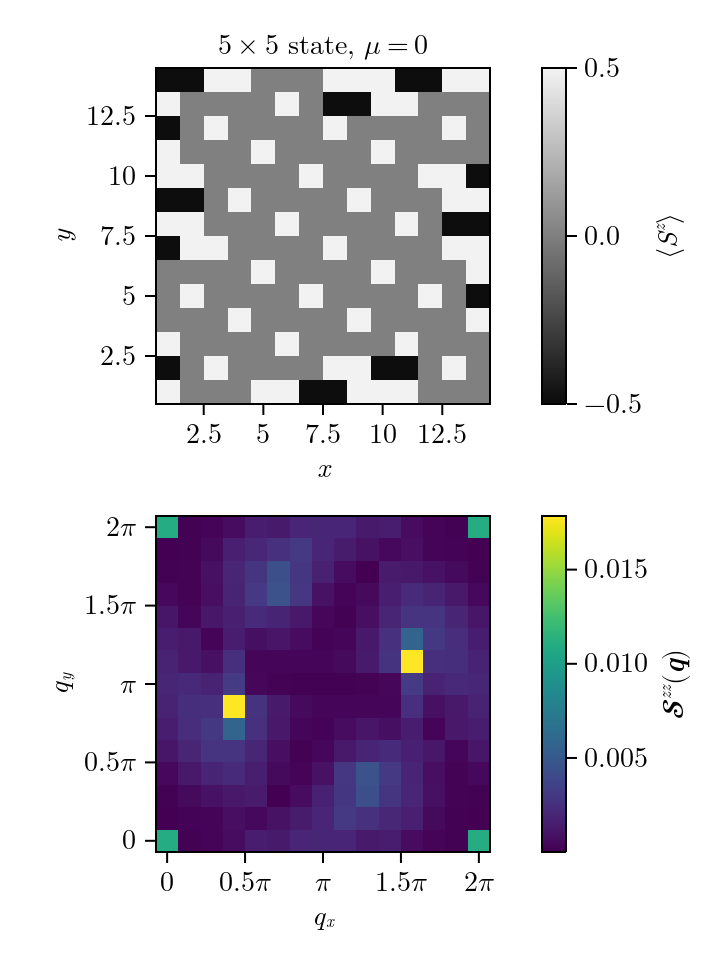

  4.654503 seconds (7.62 M allocations: 1.069 GiB, 6.31% gc time, 148.85% compilation time: 9% of which was recompilation)


CairoMakie.Screen{IMAGE}


In [4]:
μ = 0
Sol5x5 = solveED(SW.periodicState5x5(14),μ)
@time plotOverview(Sol5x5.res,Sol5x5.sol,title = L"$5×5$ state, $μ = %$μ$") |> display
save("exactFig/5x5Overview.png",current_figure())

## Overlapping plaquettes
Next, we consider a $6\times6$ state, in which the plaquettes overlap slightly.


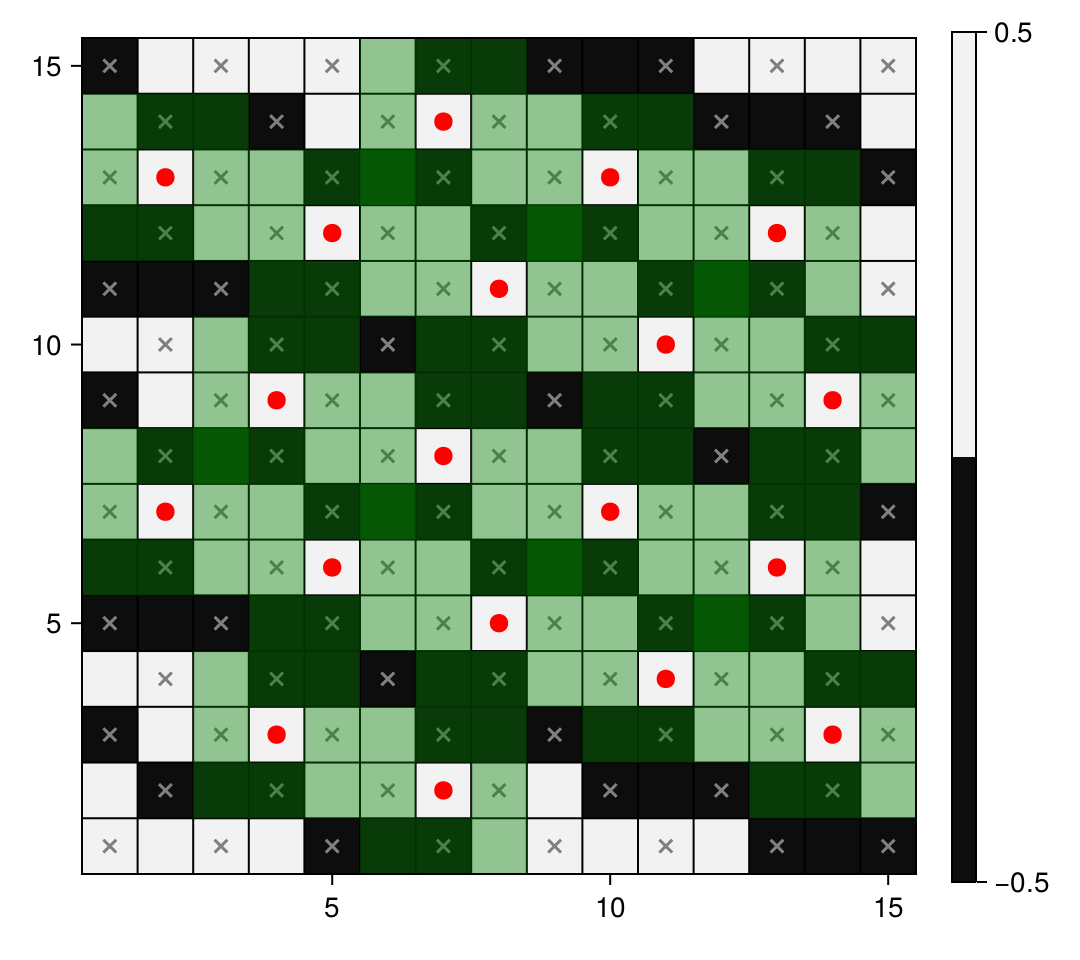

In [5]:
state6x6 = SW.periodicState6x6(15)
fig = SW.plotApplPlaquettes(state6x6,square = true)
save("figs/6x6State.png",fig)
fig

  0.328723 seconds (625.77 k allocations: 271.639 MiB)


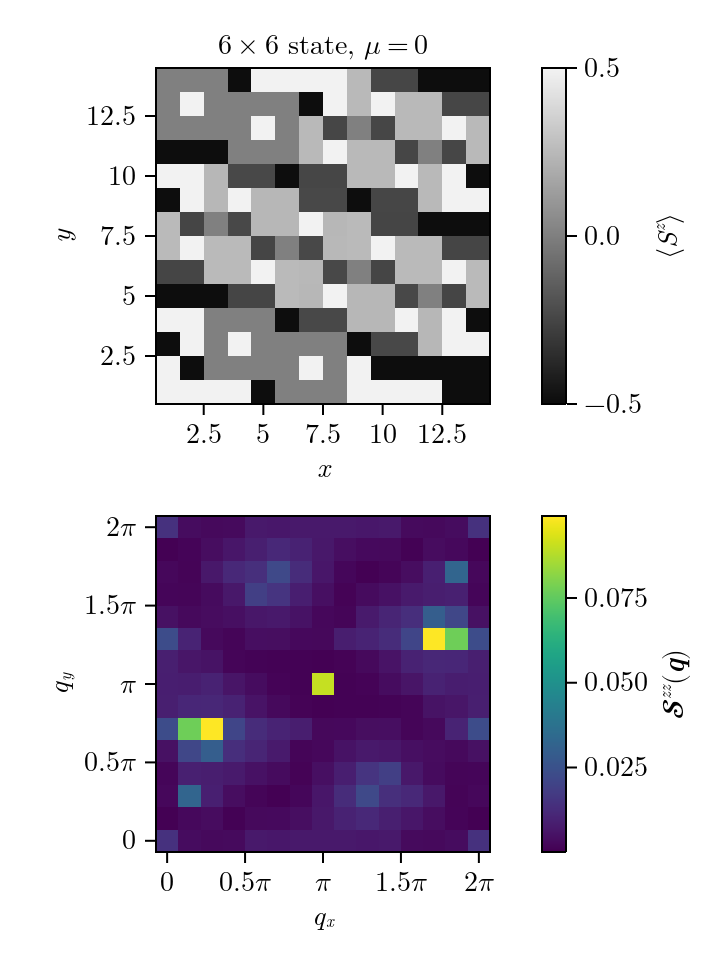

In [6]:
Sol6x6 = solveED(SW.periodicState6x6(14),μ)
@time fig = plotOverview(Sol6x6.res,Sol6x6.sol,title = L"$6×6$ state, $μ = %$μ$")
save("exactFig/6x6Overview.png",fig)
fig


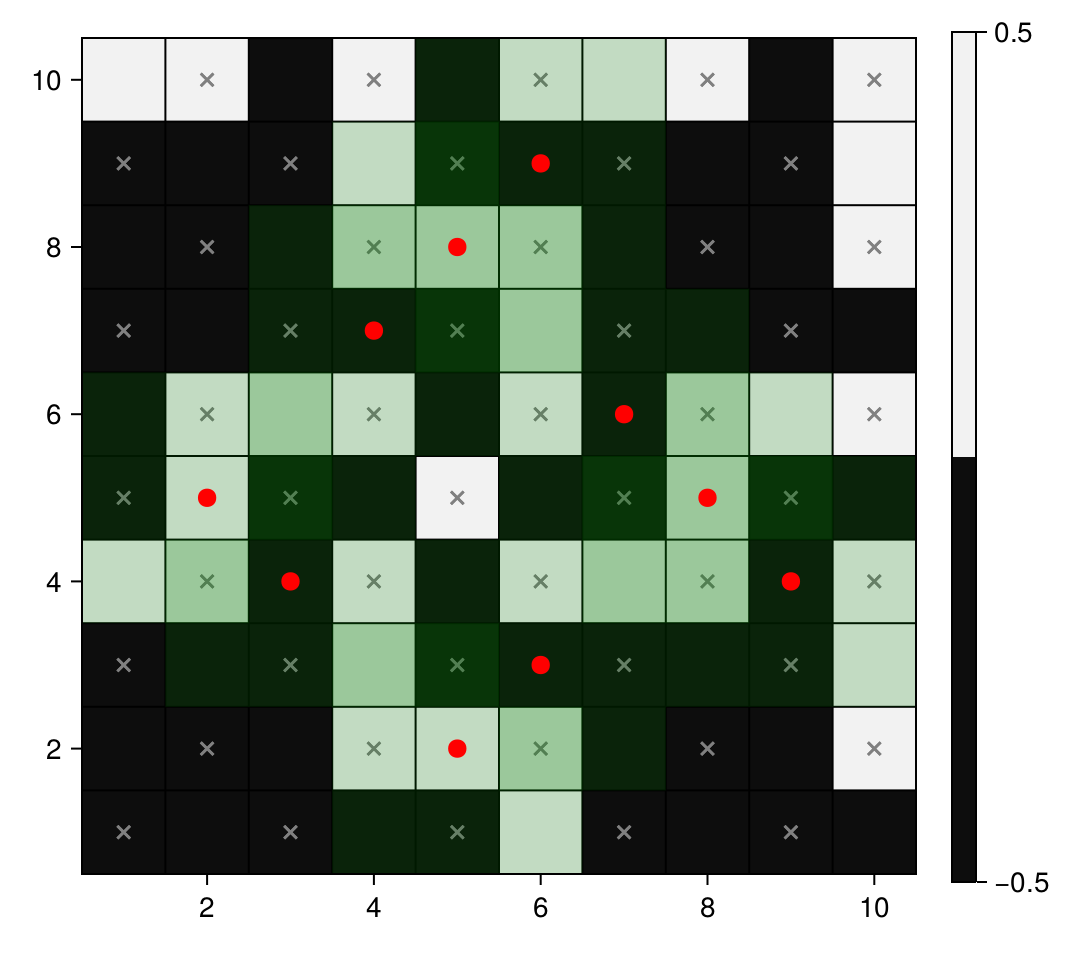

  6.934120 seconds (12.44 M allocations: 7.931 GiB, 8.38% gc time)


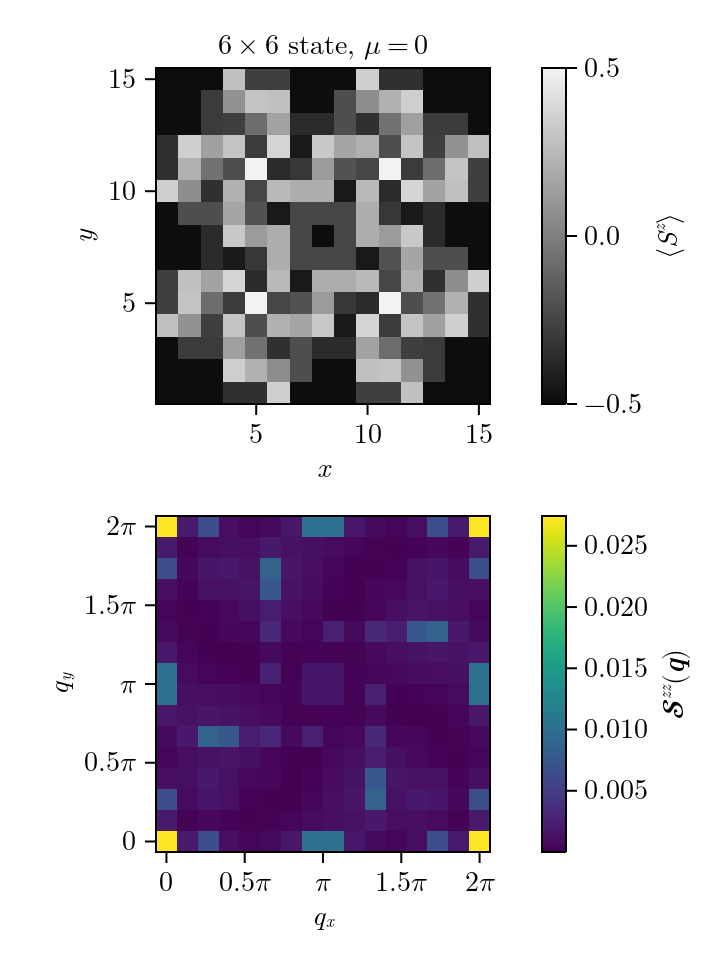

In [7]:
state6x6_3 = SW.periodicState6x6_3(10)
display(SW.plotApplPlaquettes(state6x6_3,square = (:green,0.2)))
save("figs/6x6_3State.png",current_figure())
current_figure()

state6x6_3 = SW.periodicState6x6_3(15)
Sol6x6_3 = solveED(state6x6_3,μ)
@time fig = plotOverview(Sol6x6_3.res,Sol6x6_3.sol,title = L"$6×6$ state, $μ = %$μ$")
save("exactFig/6x6_3Overview.png",fig)
fig

Finally, the state with the densest tiling of plaquettes is considered. This is the _staircase_ state

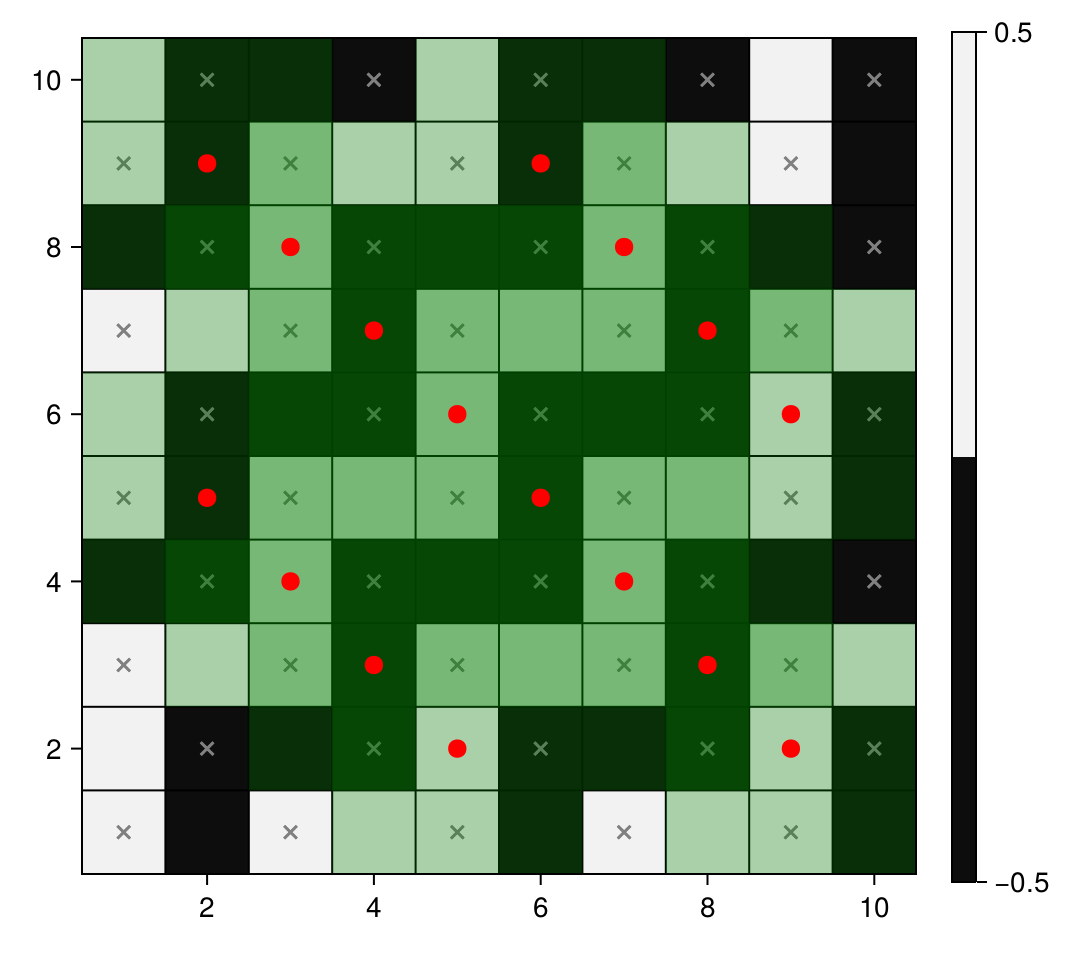

 27.856322 seconds (49.03 M allocations: 27.442 GiB, 20.87% gc time, 0.04% compilation time)


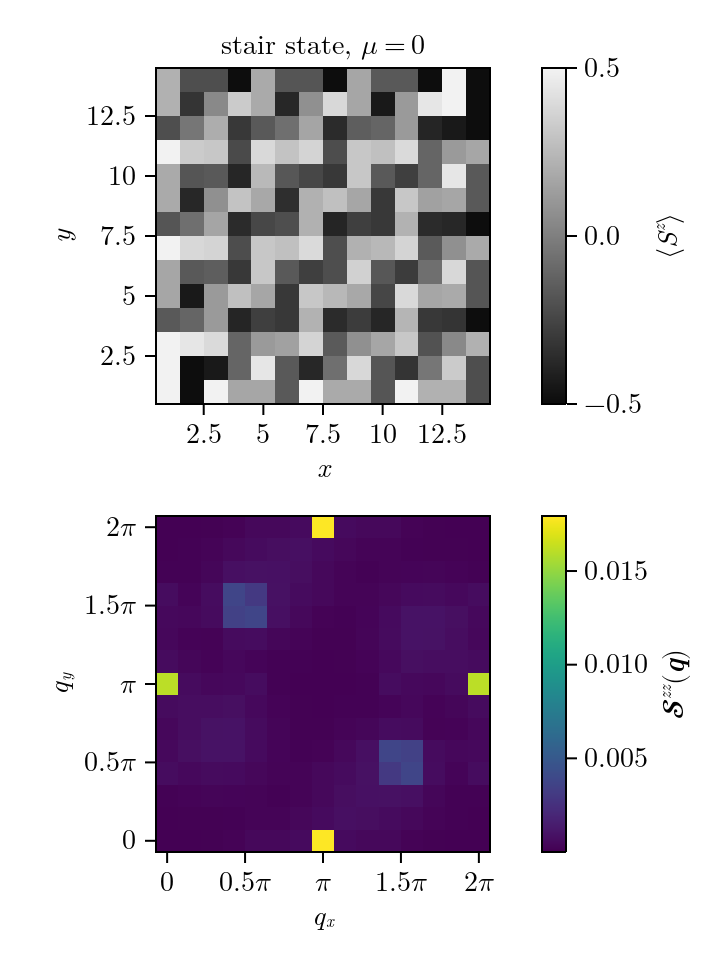

In [8]:
Stair = SW.getStairCase(10)
display(SW.plotApplPlaquettes(Stair,square = (:green,0.3)))
save("figs/StairState.png",current_figure())

SolStair = solveED(SW.getStairCase(14),μ)
@time fig = plotOverview(SolStair.res,SolStair.sol,title = L"stair state, $μ = %$μ$")
save("exactFig/StairOverview.png",fig)
fig


## At the RK point $\mu=1$
The model becomes a linear superposition of all classical states with equal weight. Here, all the sectors will contribute equally (since their energy is always zero). Nonetheless, we plot the results for the stair case state and the $6\times6$ state.

 26.133945 seconds (49.06 M allocations: 27.436 GiB, 25.67% gc time, 0.09% compilation time)


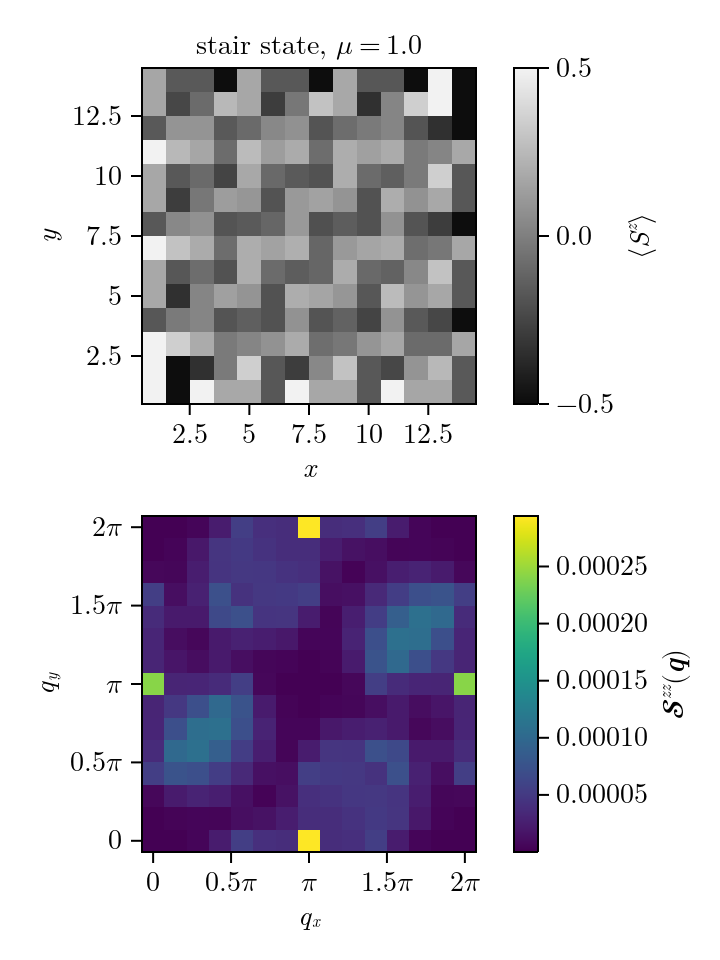

In [9]:
μ = 1.0
SolStair = solveED(SW.getStairCase(14),1.0)
@time fig = plotOverview(SolStair.res,SolStair.sol,title = L"stair state, $μ = %$μ$")
save("exactFig/StairOverview_RKPoint.png",fig)
fig

  6.370891 seconds (12.44 M allocations: 7.918 GiB, 12.86% gc time)


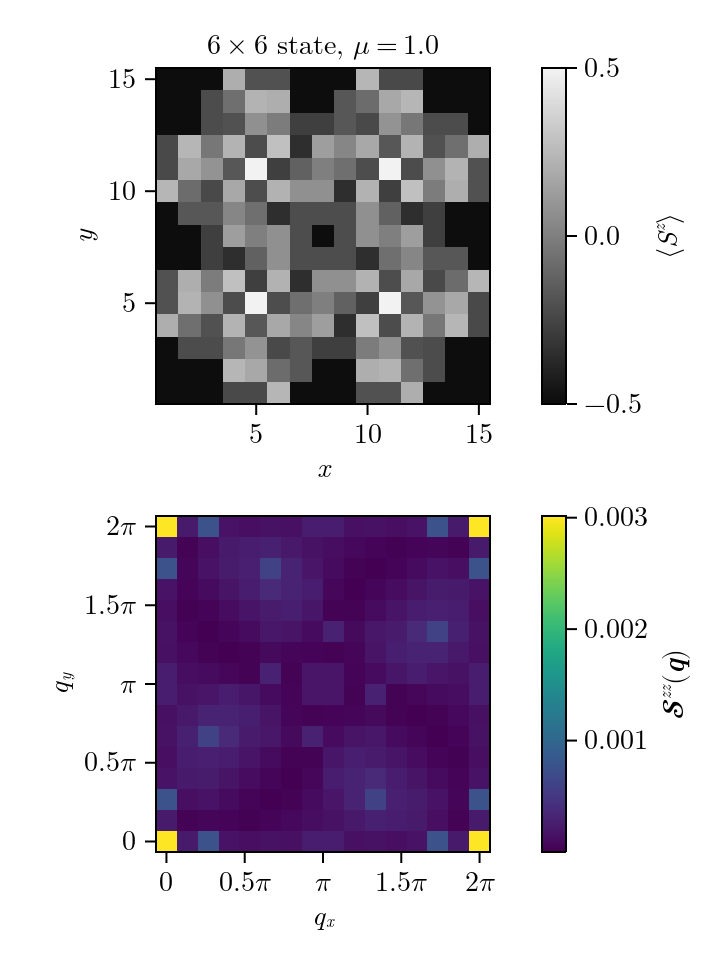

In [10]:
Sol6x6_3 = solveED(state6x6_3,μ)
@time plotOverview(Sol6x6_3.res,Sol6x6_3.sol,title = L"$6×6$ state, $μ = %$μ$")

Next, we consider the energy of the ground state as a function of system size for all states.

In [3]:
function getEnergy(sol)
    return sol.values[1]
end

function getEnergy(State::SW.SpinConfig)
    
    res = SW.getAllNeighborStates(State)
    μ = 0
    H = SW.H(res.AllStates,res.Neighbors,μ)
    sol = SW.SolveH(H)
    sol.values[1]
end


getEnergy (generic function with 2 methods)

In [12]:

StairEnergy(L) = getEnergy(getStairCase(L))
Energy5x5(L) = -length(SW.getApplicablePlaquettes(SW.periodicState5x5(L)))
Energy6x6(L) = getEnergy(SW.periodicState6x6(L))
Energy6x6_3(L) = getEnergy(SW.periodicState6x6_3(L))
Ls_small = 5:1:14
Ls_medium = 5:1:15
Ls_large = 5:1:20
@time StairEs = ([StairEnergy(L)/L^2 for L in Ls_small])
@time Ens_5x5 = ([Energy5x5(L)/L^2 for L in Ls_large])
@time Ens_6x6 = ([Energy6x6(L)/L^2 for L in Ls_medium])
@time Ens_6x6_3 = ([Energy6x6_3(L)/L^2 for L in Ls_medium])

 23.624716 seconds (49.17 M allocations: 7.962 GiB, 12.44% gc time, 0.32% compilation time)
  0.025768 seconds (29.05 k allocations: 1.978 MiB, 99.14% compilation time)


  1.145463 seconds (3.23 M allocations: 543.222 MiB, 10.82% gc time, 5.16% compilation time)


  5.752650 seconds (14.20 M allocations: 2.373 GiB, 5.67% gc time, 1.17% compilation time)


11-element Vector{Float64}:
 -0.04000000000000001
 -0.059327200140829345
 -0.05461720814276037
 -0.06746088863491956
 -0.05964146509055542
 -0.057352005001346094
 -0.06986442807259055
 -0.07027924412823558
 -0.06803881644604333
 -0.07599592458309351
 -0.07124964115588897

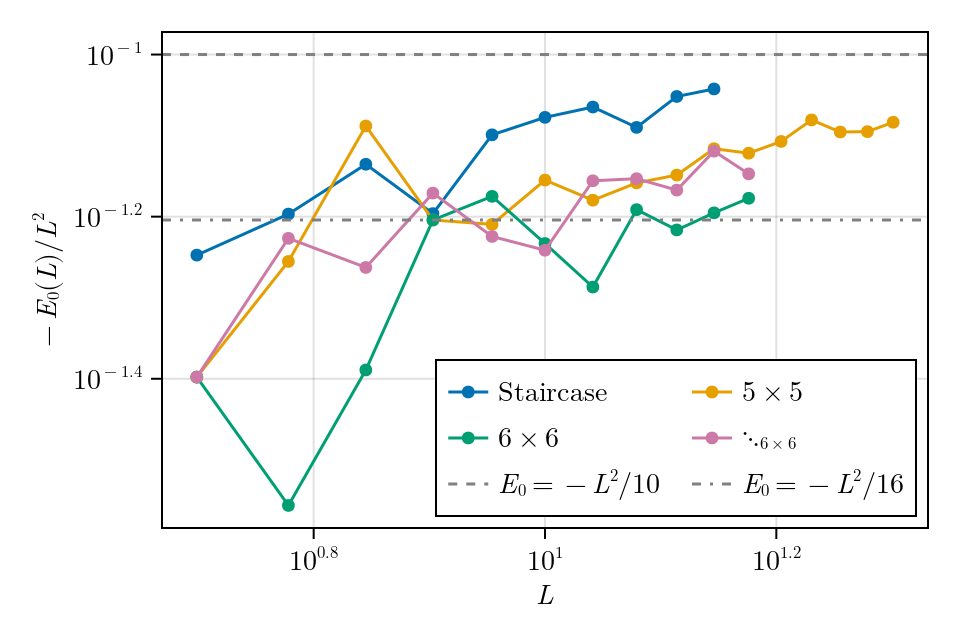

In [13]:
with_theme(theme_SimpleTicks()) do
    fig = Figure(size = 0.8 .*(600,400))
    ax = Axis(fig[1,1],xlabel = L"L",ylabel = L"-E_0(L)/L^2",
    xscale = log10,yscale = log10
    )
    scatterlines!(ax,Ls_small,-StairEs,label = L"Staircase$$")
    scatterlines!(ax,Ls_large,-Ens_5x5,label = L"5×5")
    scatterlines!(ax,Ls_medium,-Ens_6x6,label = L"6×6")
    scatterlines!(ax,Ls_medium,-Ens_6x6_3,label = L"⋱_{6×6}")
    hlines!(ax,1/10,label = L"E_0 =-L^2/10",linestyle = :dash, color = :grey)
    hlines!(ax,1/16,label = L"E_0 =-L^2/16",linestyle = :dashdot, color = :grey)
    axislegend(ax,position = :rb,nbanks = 2)
    save("exactFig/EnergyScaling.png",fig)
    fig

end


# Observations
- The staircase state has the lowest energy
- The theoretical minimum energy for **noninteracting** plaquettes (the $5\times5$ state), is $-1/10L^2$. This energy is not reached by any state. The 5x5 state does not reach this limit due to finite size effects.
- The ground state of the stair case is always gapped (see below)
# Open question:
1. Can the stair case state have an energy lower than $-1/10L^2$?
2. What is the true nature of the staircase state?

To address question 1 we consider periodic boundary conditions in which the boundary points can also fluctuate. This means that we may only consider systems with size $L=nL_\textrm{Unitcell}$, since otherwise the state would not fulfill the ice rule.

Question 2, is more difficult to answer. As a starting point, we may consider the nature of excitations. If the ground state is topological, then we expect a ground state degeneracy. 


In [4]:
function getPeriodic(parent)
    state = parent |> Array
    SW.SpinConfig(SW.PeriodicMatrix(state),parent.S)
end

getPeriodic (generic function with 1 method)

Check whether periodic boundaries work as expected: applicable plaquettes should be visible at the boundaries.
Flipping such a plaquette at the bottom should affect the top and vice versa.

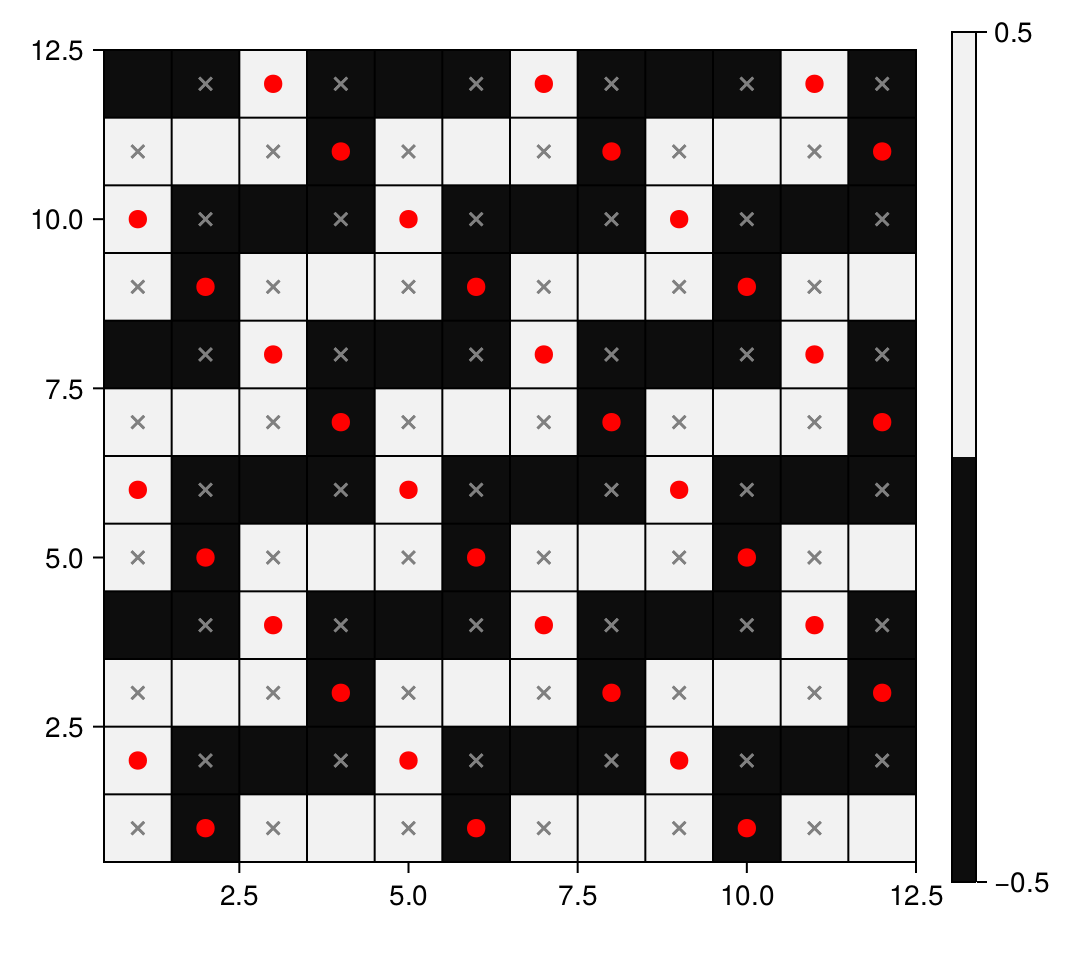

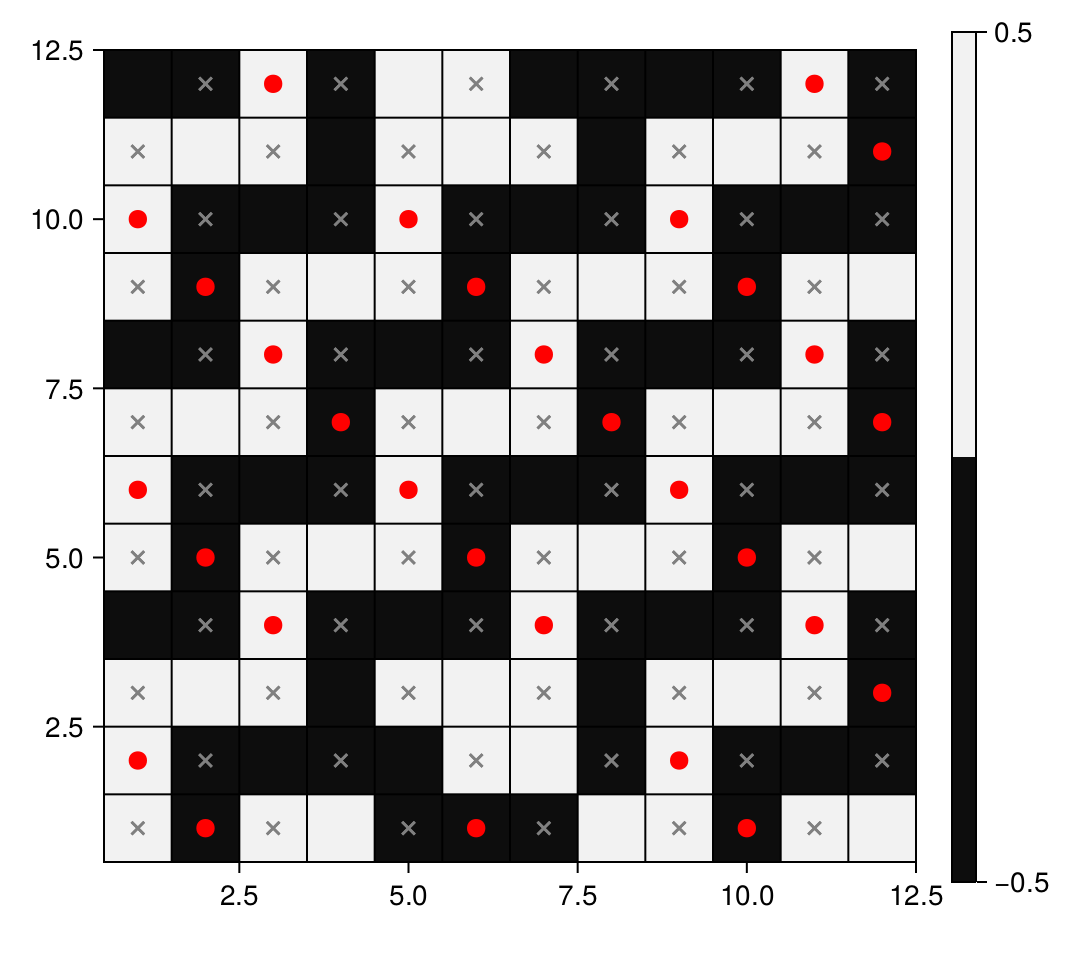

In [15]:
state = getPeriodic(SW.getStairCase(12))
SW.plotApplPlaquettes(state) |> display
SW.flipPlaquette!(state,6,1) |> SW.plotApplPlaquettes

In [16]:
StairEnergy(L) = getEnergy( getPeriodic(getStairCase(L)))
Energy5x5(L) = getEnergy( getPeriodic(SW.periodicState5x5(L)))
# Energy5x5(L) = -length(SW.getApplicablePlaquettes(getPeriodic(SW.periodicState5x5(L))))
Energy6x6(L) = getEnergy( getPeriodic(SW.periodicState6x6(L)))
Energy6x6_3(L) = getEnergy( getPeriodic(SW.periodicState6x6_3(L)))
Ls_4 = 4:4:12
Ls_5 = 5:5:15
Ls_6 = 6:6:12
StairEs = ([StairEnergy(L) for L in Ls_4])
Ens_5x5 = ([Energy5x5(L) for L in Ls_5])
Ens_6x6 = ([Energy6x6(L) for L in Ls_6])
Ens_6x6_3 = ([Energy6x6_3(L) for L in Ls_6])

2-element Vector{Float64}:
  -3.076378002641703
 -12.426379465310758

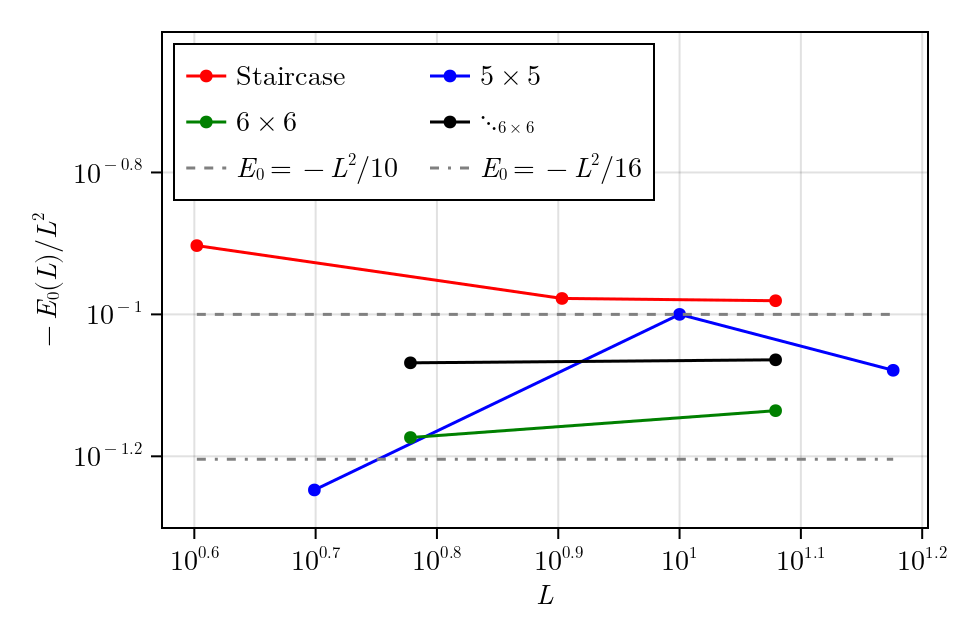

In [17]:
with_theme(theme_SimpleTicks()) do
    fig = Figure(size = 0.8 .*(600,400))
    ax = Axis(fig[1,1],xlabel = L"L",ylabel = L"-E_0(L)/L^2",
    xscale = log10,yscale = log10
    )
    scatterlines!(ax,Ls_4,-StairEs ./Ls_4.^2 ,label = L"Staircase$$",color = :red)
    scatterlines!(ax,Ls_5,-Ens_5x5 ./Ls_5.^2 ,label = L"5×5",color = :blue)
    scatterlines!(ax,Ls_6,-Ens_6x6 ./Ls_6.^2 ,label = L"6×6",color = :green)
    scatterlines!(ax,Ls_6,-Ens_6x6_3 ./Ls_6.^2 ,label = L"⋱_{6×6}", color = :black)
    LRange = LinRange(4,15,100)
    lines!(ax,LRange,1/10 .*LRange.^0 ,label = L"E_0 =-L^2/10",linestyle = :dash, color = :grey)
    lines!(ax,LRange,1/16 .*LRange.^0 ,label = L"E_0 =-L^2/16",linestyle = :dashdot, color = :grey)
    axislegend(ax,position = :lt,nbanks = 2)
    ylims!(ax,0.05,0.25)
    save("exactFig/EnergyScaling_periodic.png",fig)
    fig

end


-Except for $5\times 5$ state, other states are arguably converged 
-Staircase is slightly above the thermodynamic limit of the $5\times 5$ state 

#### How to explain the jump in $5\times 5$ state energy?
we consider the two cases $L=10,15$ with periodic boundary conditions

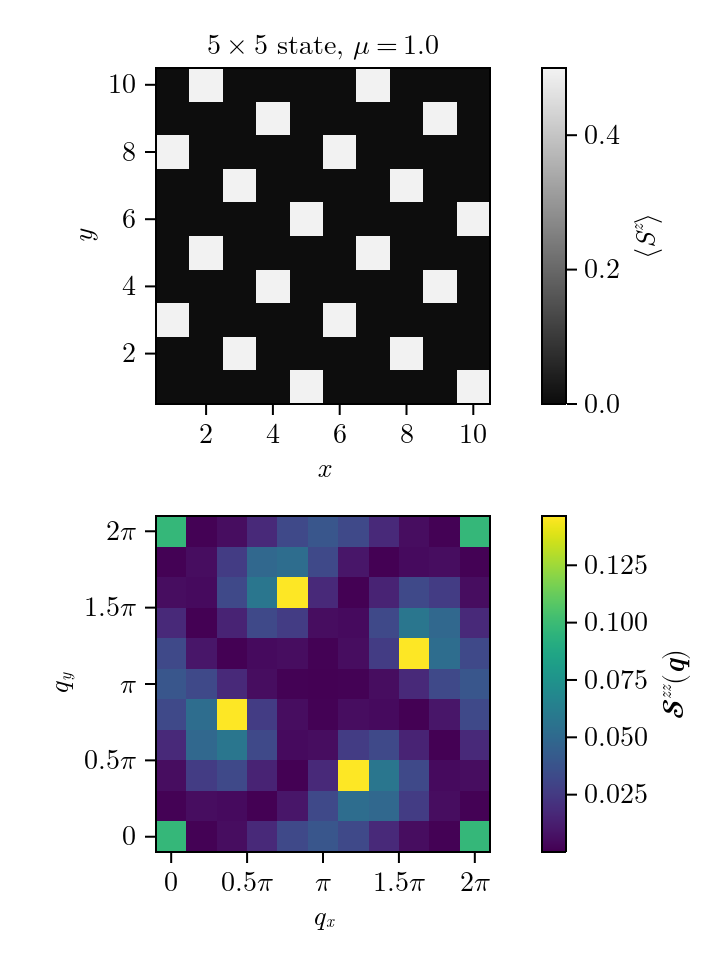

  1.232394 seconds (818.64 k allocations: 76.774 MiB, 44.84% gc time, 129.75% compilation time)


 21.299647 seconds (27.72 M allocations: 17.821 GiB, 27.49% gc time, 0.05% compilation time)


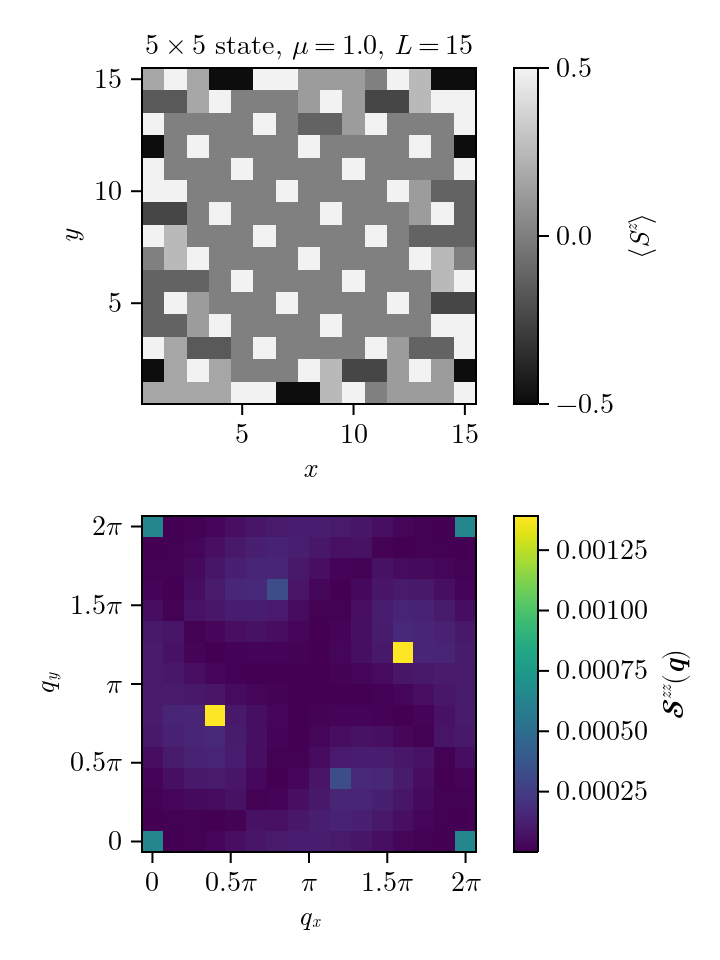

In [18]:
Sol5x5_10 = solveED(getPeriodic(SW.periodicState5x5(10)),μ)
@time display(plotOverview(Sol5x5_10.res,Sol5x5_10.sol,title = L"$5×5$ state, $μ = %$μ$"))

Sol5x5_15 = solveED(getPeriodic(SW.periodicState5x5(15)),μ)
@time plotOverview(Sol5x5_15.res,Sol5x5_15.sol,title = L"$5×5$ state, $μ = %$μ$, $L=15$")


The $L=10$ figure features no overlap between the plaquettes around the boundaries. This can be seen from the fact that the magnetization is either $0$ or $0.5$ (if the spin can never be flipped). On the other hand, the system size $L=15$ features artifacts at the boundary accreddited to the (unphysical) overlap of plaquettes which cost energy. For $L=20$, we would again expect ideal behavior $E = -L^2/16$.

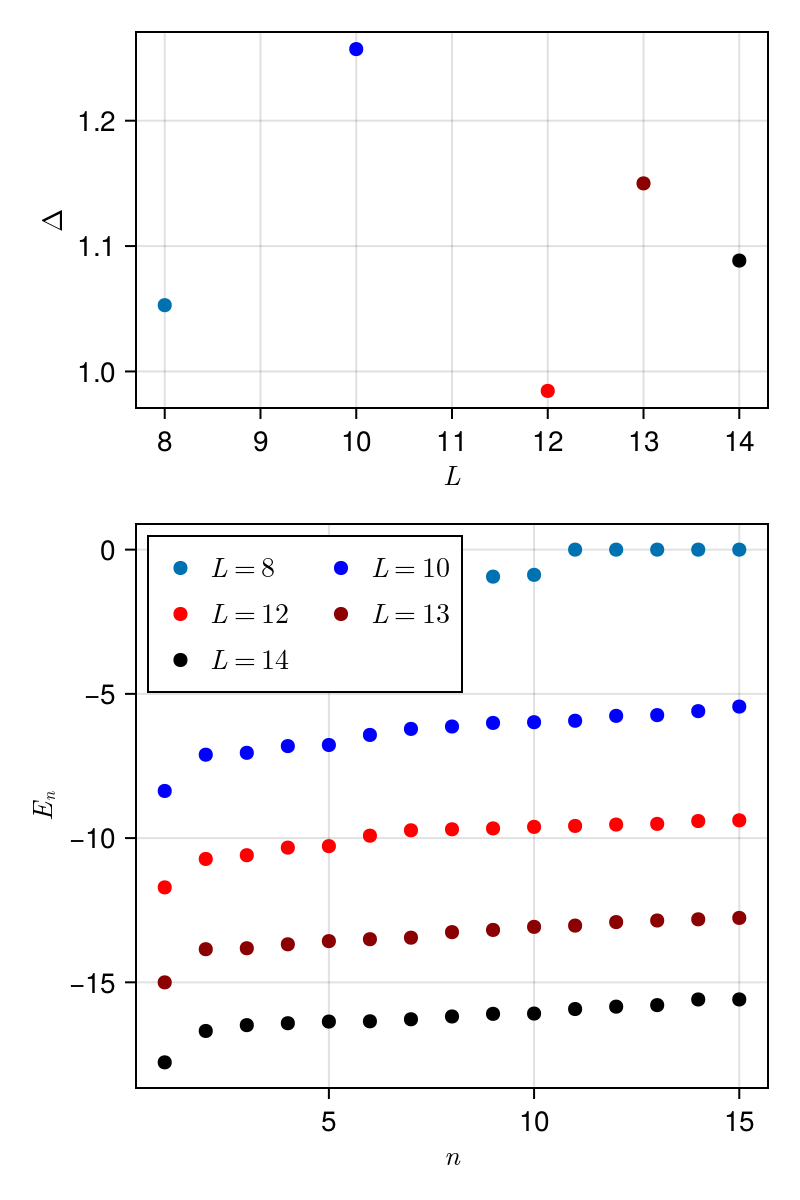

In [19]:
function plotSpectrum!(ax,axgap,L;kwargs...)
    State = getStairCase(L)
    eval = solveED(State,0,nev = 15).sol.values
    Δ = eval[2] - eval[1]
    scatter!(ax,1:length(eval),eval;kwargs...)
    scatter!(axgap,L,Δ;kwargs...)
end

let 
    fig = Figure(size = 400 .* (1,1.5))
    axgap = Axis(fig[1,1],xlabel = L"L",ylabel = L"Δ")
    ax = Axis(fig[2,1],xlabel = L"n",ylabel = L"E_n")
    plotSpectrum!(ax,axgap,8,markersize = 10,label = L"L=8")
    plotSpectrum!(ax,axgap,10,markersize = 10;color = :blue,label = L"L=10")
    plotSpectrum!(ax,axgap,12,markersize = 10;color = :red,label = L"L=12")
    plotSpectrum!(ax,axgap,13,markersize = 10;color = :darkred,label = L"L=13")
    plotSpectrum!(ax,axgap,14,markersize = 10;color = :black,label = L"L=14")
    rowsize!(fig.layout,1,Relative(0.4))
    axislegend(ax,position = :lt,nbanks = 2)
    fig
end



For open boundaries there is always a unique ground state with a clear gap. For periodic boundaries this does not change. In particular, the gap does not seem to decrease with system size, indicating no topological degeneracy in the thermodynamic limit.

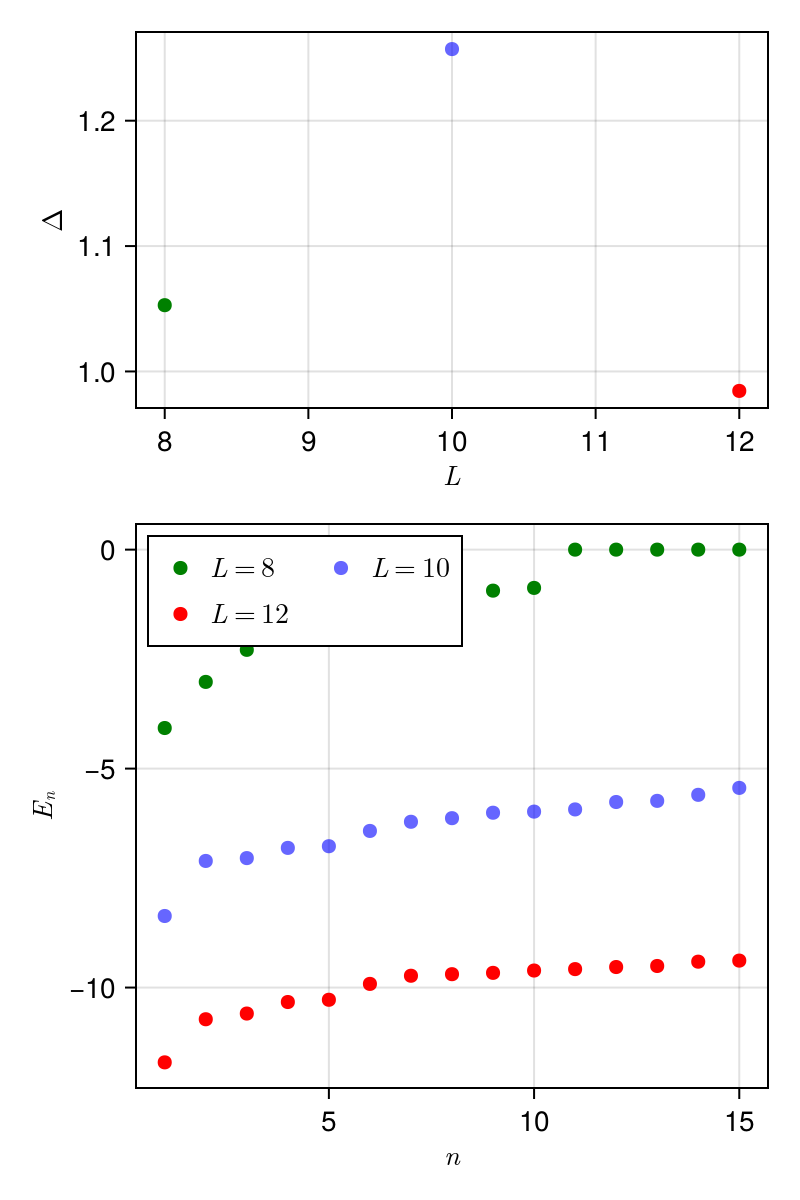

In [20]:
function plotSpectrum_periodic!(ax,axgap,L;kwargs...)
    State = getPeriodic(getStairCase(L))
    eval = solveED(State,0,nev = 15).sol.values
    Δ = eval[2] - eval[1]
    scatter!(ax,1:length(eval),eval;kwargs...)
    scatter!(axgap,L,Δ;kwargs...)
end

let 
    fig = Figure(size = 400 .* (1,1.5))
    axgap = Axis(fig[1,1],xlabel = L"L",ylabel = L"Δ")
    ax = Axis(fig[2,1],xlabel = L"n",ylabel = L"E_n")
    plotSpectrum!(ax,axgap,8,markersize = 10,color = :green,label = L"L=8")
    plotSpectrum!(ax,axgap,10,markersize = 10;color = (:blue,0.6),label = L"L=10")
    plotSpectrum!(ax,axgap,12,markersize = 10;color = :red,label = L"L=12")
    rowsize!(fig.layout,1,Relative(0.4))
    axislegend(ax,position = :lt,nbanks = 2)
    fig
end


# Rokhsar-Kivelson point:
At $\mu = 0$, the ground state is an equal superposition of all plaquette configurations.
We are interested in sampling the observable $\langle \mathcal{O} \rangle = \frac{1}{N}\sum_{n} \bra{n} \mathcal{O} \ket{n}$, where $n$ is a random state.

To generate a random configuration, we start from the parent state and flip random plaquettes.

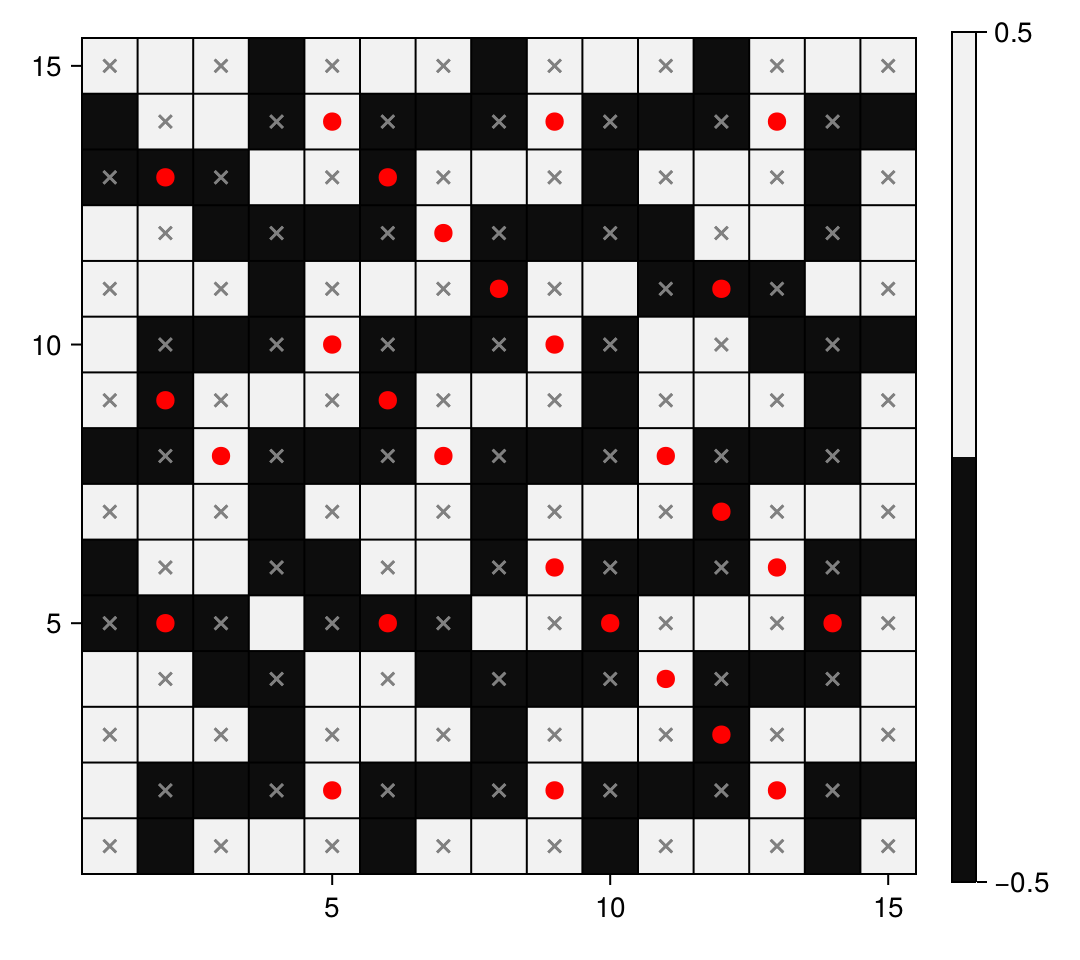

In [30]:
paths = SW.generateRandomPaths(SW.getStairCase(15),100,10)
confs = SW.spinConfig.(paths)

SW.plotApplPlaquettes(rand(confs))

In [5]:
function plotSpectrum_periodic_RK!(ax,axgap,L;kwargs...)
    State = getPeriodic(getStairCase(L))
    eval = solveED(State,1.,nev = 15).sol.values
    Δ = eval[2] - eval[1]
    scatter!(ax,1:length(eval),eval;kwargs...)
    scatter!(axgap,L,Δ;kwargs...)
end

let 
    fig = Figure(size = 400 .* (1,1.5))
    axgap = Axis(fig[1,1],xlabel = L"L",ylabel = L"Δ")
    ax = Axis(fig[2,1],xlabel = L"n",ylabel = L"E_n")
    plotSpectrum_periodic_RK!(ax,axgap,8,markersize = 10,color = :green,label = L"L=8")
    plotSpectrum_periodic_RK!(ax,axgap,10,markersize = 10;color = (:blue,0.6),label = L"L=10")
    plotSpectrum_periodic_RK!(ax,axgap,12,markersize = 10;color = :red,label = L"L=12")
    rowsize!(fig.layout,1,Relative(0.4))
    axislegend(ax,position = :lt,nbanks = 2)
    fig
end

UndefVarError: UndefVarError: `plotSpectrum!` not defined